# L96 figures and animations

In [1]:
%load_ext autoreload
%autoreload 2

from L96 import *
import matplotlib.pyplot as plt
import numpy as np
from parametrizations import *
import torch
import os
import torch.nn as nn
from util import *
import pickle
import xarray as xr
import time
from scipy.special import rel_entr  # Import KL-divergence

In [4]:
import pandas as pd
pts, dzs, losses, preds = [], [], [], []
for file in os.listdir('hyper_opt/initial_pt_tests/offline_R2/'):
    if 'pkl' in file:
        model = torch.load('hyper_opt/initial_pt_tests/offline_R2/' + file, map_location='cpu', weights_only=False)
        pts.append(model.past_timesteps)
        dzs.append(model.latent_dims)
        losses.append(np.mean(model.R2[-1]))
        # preds.append(np.mean(model.nonlinear_predictability.detach().cpu().numpy()))

df = pd.DataFrame(np.array([pts, dzs, losses]).T, columns=['M', 'd_z', 'test loss'])
df = df.sort_values(['d_z', 'M'])
# Format the columns as requested
df['M'] = df['M'].astype(int)           # M as integer
df['d_z'] = df['d_z'].astype(int)       # d_z as integer
df['test loss'] = df['test loss'].map('{:.3f}'.format)  # 3 decimal places
#df['upper predictability boundary R^2'] = df['upper predictability boundary R^2'].map('{:.2f}'.format)  # 2 decimal places

df.to_latex('hyper_opt/initial_pt_tests/offline_R2/summary_latex_table', index=False)
df

,M,d_z,test loss
3,10,4,0.882
2,100,4,0.919
0,1000,4,0.931
4,10,8,0.882
1,100,8,0.919
5,1000,8,0.937


In [2]:
model10 = torch.load('hyper_opt/initial_pt_tests/m=0.001_tau=0.001_init_hyper_opt_pt=10_20260603131555.pkl', map_location='cpu', weights_only=False)
model100 = torch.load('hyper_opt/initial_pt_tests/m=0.001_tau=0.001_init_hyper_opt_pt=100_20260603131920.pkl', map_location='cpu', weights_only=False)
model1000 = torch.load('hyper_opt/initial_pt_tests/m=0.001_tau=0.001_init_hyper_opt_pt=1000_20260603132655.pkl', map_location='cpu', weights_only=False)

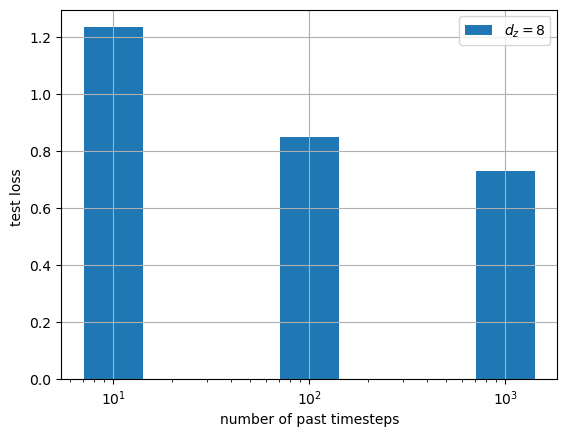

In [31]:
x, height = [], []

for model in [model10, model100, model1000]:
    x.append(model.past_timesteps)
    height.append(min(model.test_loss))

plt.xscale("log")
padded_x = [x[0] / 10] + x + [x[-1] * 10]
width = 0.3  # 1 for full width, closer to 0 for thinner bars
lefts = [x1 ** (1 - width / 2) * x0 ** (width / 2) for x0, x1 in zip(padded_x[:-2], padded_x[1:-1])]
rights = [x0 ** (1 - width / 2) * x1 ** (width / 2) for x0, x1 in zip(padded_x[1:-1], padded_x[2:])]
widths = [r - l for l, r in zip(lefts, rights)]
plt.bar(lefts, height, widths, align='edge', facecolor='tab:blue', label=r'$d_z=8$')
plt.grid()
plt.xlabel('number of past timesteps')
plt.ylabel('test loss ')
plt.legend()

In [5]:
import os 
latent_dims = 2
paths = []
for file in os.listdir(f'networks/NN+AE+D/latent_dims={latent_dims}_past_timesteps=1000_n_neighbours=0'):
    if 'hyper_opt' in file:
        paths.append(file)
paths 

['m=0.001_tau=0.001_hyper_opt_w=0.0001_20260528104332.pkl',
 'm=0.001_tau=0.001_hyper_opt_w=0.0_20260528110528.pkl',
 'm=0.001_tau=0.001_hyper_opt_w=0.001_20260528103559.pkl',
 'm=0.001_tau=0.001_hyper_opt_w=1e-05_20260528105041.pkl',
 'm=0.001_tau=0.001_hyper_opt_w=1e-06_20260528105817.pkl']

In [2]:
path = '/work/bd1179/b309297/L96/networks/ODE_Z_online/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_20250912144018.pkl'
L96_model = torch.load(path, map_location='cpu', weights_only=False)

In [9]:
L96_model.coefs

tensor([[-1.4268e+01,  5.3121e+00, -1.3678e+01, -9.7914e-01,  2.6187e+01,
          5.4487e+00, -1.3811e+01,  7.4602e+00],
        [-3.2319e+00, -4.0539e+00, -2.3484e+00, -1.0184e+00, -1.2813e-01,
         -3.3134e+00, -5.0678e-03, -3.0644e+00],
        [ 3.3748e+00, -3.2403e-01,  1.3343e+00, -2.4625e+00, -3.3657e+00,
          7.5948e-02,  2.4550e+00, -2.0151e+00],
        [ 7.0487e-01, -1.9641e+00, -2.8192e+00,  4.3571e+00, -1.6006e+00,
         -2.6508e+00,  4.1144e+00,  2.7762e+00],
        [-4.8483e+00,  4.6957e+00, -6.4591e+00, -9.9788e-01, -4.5529e+00,
         -1.6529e+00,  9.1673e-01,  3.2322e+00],
        [ 4.4146e-01, -2.4204e+00, -3.9505e-02, -8.2394e-01, -1.6236e+00,
         -8.7142e+00, -4.0629e+00,  4.8350e+00],
        [ 1.7853e+00, -1.4217e+00,  2.8380e+00, -5.1056e+00,  1.7292e+01,
         -1.7261e+00, -7.2196e+00, -2.6518e+00],
        [-1.9877e-01,  5.2940e-03, -4.8932e+00, -3.7804e+00,  1.1048e+01,
          1.4695e+00, -4.5212e+00, -2.3736e+00],
        [ 2.0404

In [ ]:
np.load('ODEs/m=0.001_tau=0.001/dim=8_decoder=True_deg=1_lambda=0.0_finitedifference.npy')

(8, 10)

In [2]:
merge_time('ODE_Z_online/latent_dims=6_past_timesteps=1000_n_neighbours=0', m=0.001, tau=0.001, timestamp='202606021417')

In [7]:
merge_time('NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0', m=1.0, tau=100.00, timestamp='202509191417')

In [3]:
# Load initial conditions for L96 model_autoencoder_autoencoder
initX, initY = np.load('./initX.npy'), np.load('./initY.npy')
np.random.seed(123)

In [6]:
L96 = xr.open_dataset('online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=7/m=1.0_tau=100.0_t=50000MTU_202509191417.nc')
L96.time

<xarray.DataArray 'time' (time: 100000000)> Size: 800MB
array([30000.   , 30000.001, 30000.002, ..., 35999.997, 35999.998, 35999.999],
      shape=(100000000,))
Coordinates:
  * time     (time) float64 800MB 3e+04 3e+04 3e+04 ... 3.6e+04 3.6e+04 3.6e+04

(array([  19.,   10.,   10.,   19.,   18.,   35.,   72.,   74.,   63.,
         158.,  162.,  191.,  278.,  263.,  634., 1136., 2125., 3130.,
        3430., 3657., 3987., 3799., 3807., 3012., 2565., 2428., 1789.,
        1773., 1881., 1593., 1290., 1242., 1241., 1175., 1273., 1309.,
        1667., 1659., 1529., 1409., 1528., 1370., 1301., 1171.,  736.,
         641.,  549.,  460.,  246.,   86.]),
 array([-16.76086426, -16.28250836, -15.80415247, -15.32579658,
        -14.84744068, -14.36908479, -13.89072889, -13.412373  ,
        -12.93401711, -12.45566121, -11.97730532, -11.49894942,
        -11.02059353, -10.54223763, -10.06388174,  -9.58552585,
         -9.10716995,  -8.62881406,  -8.15045816,  -7.67210227,
         -7.19374638,  -6.71539048,  -6.23703459,  -5.75867869,
         -5.2803228 ,  -4.80196691,  -4.32361101,  -3.84525512,
         -3.36689922,  -2.88854333,  -2.41018744,  -1.93183154,
         -1.45347565,  -0.97511975,  -0.49676386,  -0.01840796,
          0.45994793,   

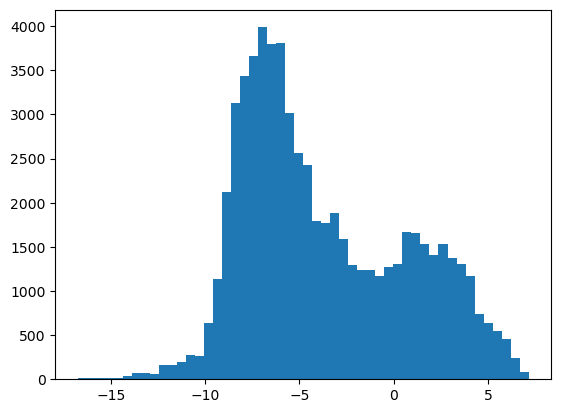

In [49]:
Z, X, B = L96.Z.values[2000:], L96.X.values[2000:], L96.B.values[2000:]  # discard first 2MTUs
t = np.arange(len(X)) * .001
plt.hist(B.flatten(), bins=50)

In [3]:
L96 = xr.open_dataset('online_runs/ODE_Z/input_lagg=1000/time=1000MTU_m=0.001_tau=0.001_faster.nc')
L96

<xarray.Dataset> Size: 1GB
Dimensions:      (time: 1000000, x: 8, latent_dims: 8, y: 256)
Coordinates:
  * time         (time) float64 8MB 0.0 0.001 0.002 0.003 ... 1e+03 1e+03 1e+03
  * y            (y) int32 1kB 0 1 2 3 4 5 6 7 ... 249 250 251 252 253 254 255
  * x            (x) int32 32B 0 1 2 3 4 5 6 7
  * latent_dims  (latent_dims) int32 32B 0 1 2 3 4 5 6 7
Data variables:
    Z_ODE        (time, x, latent_dims) float64 512MB ...
    Z            (time, x, latent_dims) float64 512MB ...
    X            (time, x) float32 32MB ...
    B            (time, x) float32 32MB ...
Attributes:
    m:               0.001
    tau:             0.001
    model:           ODE_Z
    past_timesteps:  1000
    model_path:      networks/ODE_Z/input_lagg=1000/m=0.001_tau=0.001_ODE_Z_f...
    latent_dims:     8

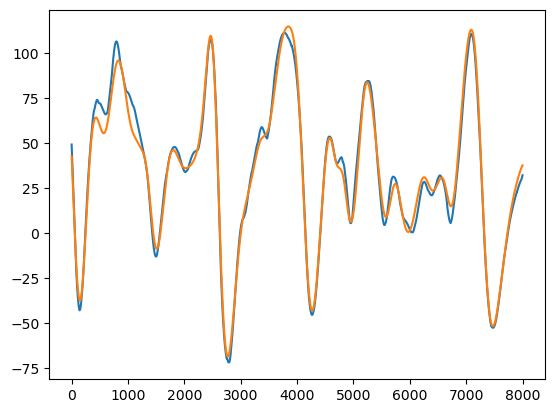

In [4]:
Z, Z_ODE, X, B = L96.Z.values[2000:], L96.Z_ODE.values[2000:], L96.X.values[2000:], L96.B.values[2000:]  # discard first 2MTU
k,i = 0, 1
plt.plot(Z[990_000:, k, i])
plt.plot(Z_ODE[990_000:, k, i])

In [5]:
# with open('networks/NN+AE+D/input_lagg=1000/m=0.001_tau=0.001_NN+AE+D_w=0.0001.pkl', 'rb') as file:
with open('networks/NN+AE+D/input_lagg=1000/m=0.001_tau=0.001_NN+AE+D_w=0.001_for_ODE_more_data.pkl', 'rb') as file:
    model = torch.load(file, weights_only=False, map_location=device)

max(model.R2)

tensor(0.9372, device='cuda:0')

In [6]:
to_tensor = lambda x: torch.tensor(x, dtype=torch.float32, device=device)
Xt, Bt, Z_ODEt = to_tensor(X.reshape(-1, 1)), to_tensor(B.reshape(-1, 1)), to_tensor(Z_ODE.reshape(-1, 8))

x = torch.cat((Z_ODEt, Xt), dim=1)
model.eval()
with torch.no_grad():
    B_NN = model.neural_net(x)

In [7]:
from torchmetrics.regression import R2Score
print(B_NN.shape, Bt.shape)
R2Score()(B_NN, Bt)

torch.Size([7984000, 1]) torch.Size([7984000, 1])


tensor(0.9293, device='cuda:0')

Text(0, 0.5, 'B')

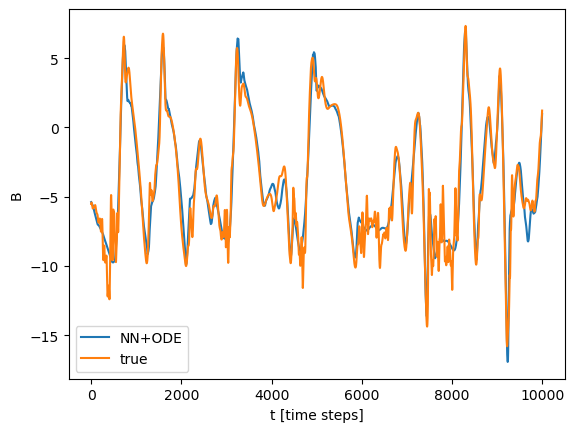

In [11]:
b_nn = B_NN.cpu().detach().numpy().flatten()
b = Bt.cpu().detach().numpy().flatten()
plt.plot(b_nn[:8*10_000:8], label='NN+ODE')
plt.plot(b[:8*10_000:8], label='true')
plt.legend()
plt.xlabel('t [time steps]')
plt.ylabel('B')

In [12]:
# Retrain NN to predict true B from Z_ODE
model = NNpODE(1000, latent_dims=8)
Ntrain = int(x.shape[0] * 0.8)

X_train, X_test = x[:Ntrain], x[Ntrain:]
B_train, B_test = Bt[:Ntrain], Bt[Ntrain:]

train_model(X_train, X_test, B_train, B_test, model, num_epochs=5000)

Training: 100%|████████████████████████████| 5000/5000 [04:21<00:00, 19.10it/s, Train Loss=1.3462, Test Loss=1.3461, R²=0.9358, Best R²=0.9363 @ 4974]


NNpODE(
  (neural_net): Sequential(
    (0): Linear(in_features=9, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

# Online Evaluation

# Compare different "Climates"

In [2]:
def L96_from_nc(path):
    XB = xr.load_dataset(path)
    L96 = L962LvlMem()
    L96._history_X = XB.X
    L96._history_B = XB.B

    return L96

In [3]:
# Load 50_000 MTU runs
m, tau = 0.001, 0.001
# m, tau = 1.0, 100.0
if (m==0.001) and (tau==0.001):
    L96_true = L96_from_nc(f'online_runs/NO_PARAMETRIZATION/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc')
    L96_nonlocal = L96_from_nc('online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=7/m=0.001_tau=0.001_t=50000MTU_202509181417.nc')
    #L96_ODE = L96_from_nc('online_runs/ODE_Z_online/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc')
    L96_ODE = L96_from_nc('online_runs/ODE_Z_online/latent_dims=6_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_202606021417.nc')
    L96_base = L96_from_nc('online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_202509181417.nc')
    L96_ae81 = L96_from_nc('online_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=50000MTU_20250918101458.nc')
else:
    L96_true = L96_from_nc(f'online_runs/NO_PARAMETRIZATION/m=1.0_tau=100.0_t=50000MTU_202509191417.nc')
    L96_nonlocal = L96_from_nc('online_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=7/m=1.0_tau=100.0_t=50000MTU_202509191417.nc')
    L96_ODE = L96_from_nc('online_runs/ODE_Z_online/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=1.0_tau=100.0_t=50000MTU_202509191417.nc')
    # L96_base = L96_from_nc(path)
    L96_ae81 = L96_from_nc('online_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=1.0_tau=100.0_t=50000MTU_202509191417.nc')



$\phi_{8,1}$
$\phi_{8,1,ED}$
$\phi_{0,0}$
$\phi_{0,0,\text{non-local}}$


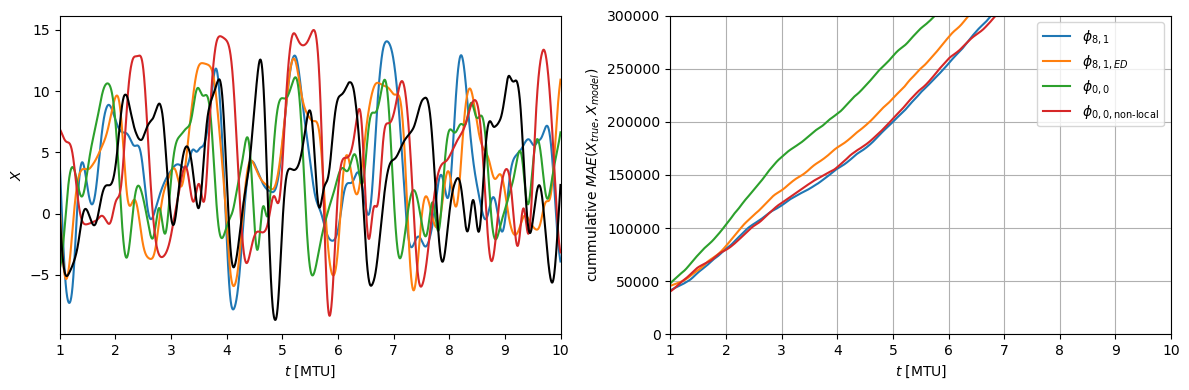

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
tmax = 10_000
X_true = L96_true.history.X.values[:tmax]
t = np.arange(0, len(X_true)  ) *L96_true.dt 
k = 2

for L96, model_name in zip([L96_ae81, L96_ODE, L96_base, L96_nonlocal], [r'$\phi_{8,1}$', r'$\phi_{8,1,ED}$', r'$\phi_{0,0}$', r'$\phi_{0,0,\text{non-local}}$']):
    print(model_name)
    X = L96.history.X.values[:tmax]
    MAE = np.cumsum(np.sum(np.absolute(X_true-X), axis=1))
    axs[1].plot(t, MAE, label=model_name)
    axs[0].plot(t, X[:, k], label=model_name)

#X_true = L96_true.history.X.values[:tmax, k]
axs[0].plot(t, X_true[:, k], label='true', color='black')

axs[1].legend()
axs[1].set(xlabel=r'$t$ [MTU]', ylabel=r'$MAE(X_{true}, X_{model})$', xlim=(1, 10), ylim=(0, 300_000))
axs[0].set(xlabel=r'$t$ [MTU]', ylabel=r'$X$', xlim=(1, 10))
plt.xlabel(r'$t$ [MTU]')
plt.ylabel(r'cummulative $MAE(X_{true}, X_{model})$')
plt.grid()
plt.tight_layout()

Number of bins (X, B):  1404 1834


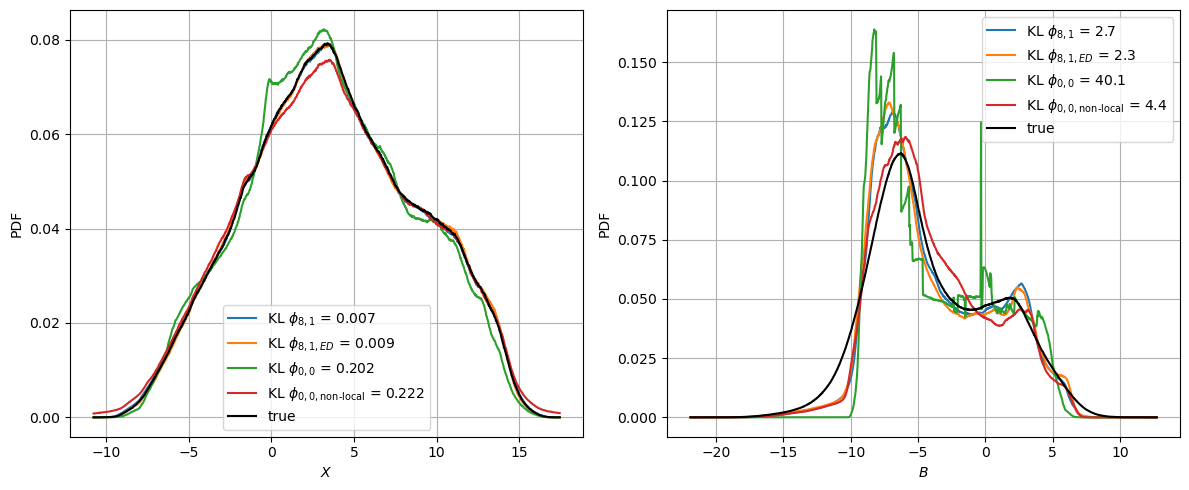

In [5]:
tmin, tmax = None, None 
B_true = L96_true.history.B.values.flatten()[:tmax]
X_true = L96_true.history.X.values.flatten()[:tmax]
Xbins = np.histogram_bin_edges(X_true, bins='fd')
Bbins = np.histogram_bin_edges(B_true, bins='fd')
# Xbins = np.histogram_bin_edges(X_true, bins=827)
# Bbins = np.histogram_bin_edges(B_true, bins=827)
print('Number of bins (X, B): ', len(Xbins), len(Bbins))
P_X_true, _ = np.histogram(X_true, bins=Xbins, density=True)
P_B_true, _ = np.histogram(B_true, bins=Bbins, density=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.set(xlabel=r'$X$', ylabel='PDF')
ax2.set(xlabel=r'$B$', ylabel='PDF')

for L96, model_name in zip([L96_ae81, L96_ODE, L96_base, L96_nonlocal], [r'$\phi_{8,1}$', r'$\phi_{8,1,ED}$', r'$\phi_{0,0}$', r'$\phi_{0,0,\text{non-local}}$']):
    B = L96.history.B.values.flatten()[:tmax]
    X = L96.history.X.values.flatten()[:tmax]

    P_X, _ = np.histogram(X, bins=Xbins, density=True)
    P_B, _ = np.histogram(B, bins=Bbins, density=True)

    eps = 1.e-12
    ax1.plot(Xbins[1:], P_X, label=f'KL {model_name} = {round(np.sum(rel_entr(P_X_true, P_X + eps)), 3)}')
    ax2.plot(Bbins[1:], P_B, label=f'KL {model_name} = {round(np.sum(rel_entr(P_B_true, P_B + eps)), 1)}')

ax1.plot(Xbins[1:], P_X_true, label=f'true', c='black')
ax2.plot(Bbins[1:], P_B_true, label=f'true', c='black')

for ax in [ax1, ax2]:
    ax.legend()
    ax.grid()

plt.tight_layout()

In [6]:
tmin, tmax = None, None 
X_true = L96_true.history.X.values.flatten()[:tmax]
Xbins = np.histogram_bin_edges(X_true, bins='fd')
print('Number of bins X: ', len(Xbins))
P_X_true, _ = np.histogram(X_true, bins=Xbins, density=True)
P_B_true, _ = np.histogram(B_true, bins=Bbins, density=True)

P_Xs = []
for L96, model_name in zip([L96_ae81, L96_ODE, L96_base, L96_nonlocal], [r'$\phi_{8,1}$', r'$\phi_{8,1,ED}$', r'$\phi_{0,0}$', r'$\phi_{0,0,\text{non-local}}$']):
    X = L96.history.X.values.flatten()[:tmax]

    P_X, _ = np.histogram(X, bins=Xbins, density=True)
    P_Xs.append(P_X)


Number of bins X:  1404


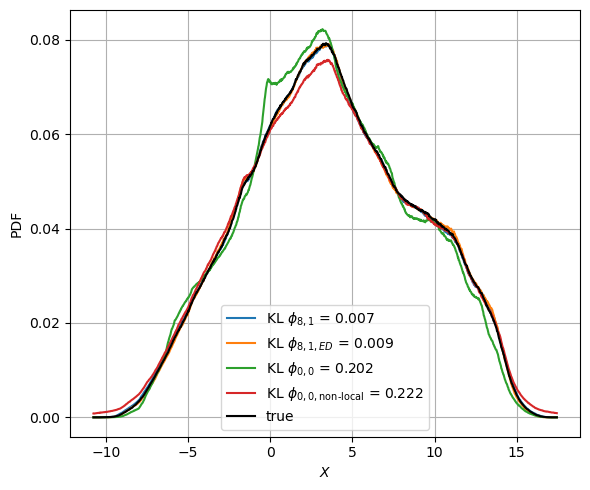

In [7]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))
ax1.set(xlabel=r'$X$', ylabel='PDF')

for P_X, model_name in zip(P_Xs, [r'$\phi_{8,1}$', r'$\phi_{8,1,ED}$', r'$\phi_{0,0}$', r'$\phi_{0,0,\text{non-local}}$']):
    eps = 1.e-12
    ax1.plot(Xbins[1:], P_X, label=f'KL {model_name} = {round(np.sum(rel_entr(P_X_true, P_X + eps)), 3)}')
ax1.plot(Xbins[1:], P_X_true, label=f'true', c='black')

for ax in [ax1, ax2]:
    ax.legend()
    ax.grid()

plt.tight_layout()

# Significant Weather Analysis

In [8]:
def get_X_weather(base_path, m, tau, sim_time=13, K=8):
    files = os.listdir(base_path)
    nruns=500

    X = np.zeros(shape=(nruns, sim_time*1000, K))
    for file in files:
        if (f'm={m}' in file) and (f'tau={tau}' in file): 
            seed = int(file.split('seed=')[1].split('_')[0])
            L96 = xr.open_dataset(base_path + file)
            X[seed] = L96.X.values
    return X

Xw_true = get_X_weather('weather_runs/NO_PARAMETRIZATION/', 0.001, 0.001, 7)
# X_ODE = get_X_weather('weather_runs/ODE_Z_online/latent_dims=8_past_timesteps=1000_n_neighbours=0/', 0.001, 0.001, 7)
X_ODE = get_X_weather('weather_runs/ODE_Z_online/latent_dims=6_past_timesteps=1000_n_neighbours=0/', 0.001, 0.001, 7)
X_base = get_X_weather('weather_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=0/', 0.001, 0.001, 7)
X_nonlocal = get_X_weather('weather_runs/NN/latent_dims=0_past_timesteps=0_n_neighbours=7/', 0.001, 0.001, 7)
X_AE = get_X_weather('weather_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/', 0.001, 0.001, 7)

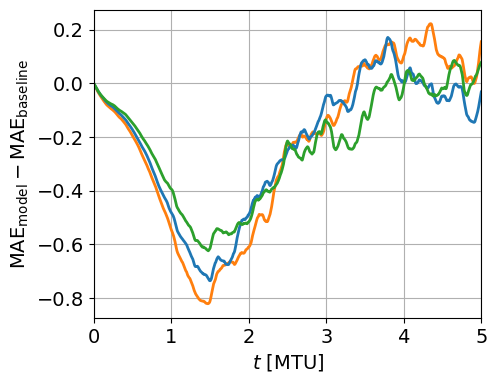

In [21]:
Xs = [X_base, X_AE, X_ODE, X_nonlocal]
model_names = ['autoencoder', 'linear ODE', 'baseline', 'non-local baseline']
colors=['tab:purple', 'tab:orange', 'tab:blue', 'tab:green']
# Xs = [X_base, X_nonlocal, X_ODE]
# model_names = [r'$\phi_{0,0,1}$', r'$\phi_{0,0,8}$', r'$\phi_{8,1,1,ODE}$']

def plot_MAE_weather(X_true, Xs, model_names, trunc_sims=None, fig=None, ax=None, colors=colors):
    if fig:
        pass
    else:
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    if trunc_sims:
        Xs = [X[:trunc_sims] for X in Xs]
        X_true = X_true[:trunc_sims]

    t = np.arange(X_true.shape[1]) * .001 - 2
    MAE = np.sum(np.absolute(X_true - Xs[0]), axis=2) / 8
    mean_MAE_base = np.mean(MAE, axis=0)
    for X, model_name, color in zip(Xs[1:], model_names[1:], colors[1:]):
        MAE = np.sum(np.absolute(X_true - X), axis=2) / 8
        mean_MAE = np.mean(MAE, axis=0)
        std_MAE = np.std(MAE, axis=0)
        #ax.plot(t, mean_MAE, label=model_name)
        ax.plot(t, mean_MAE - mean_MAE_base, label=model_name, c=color)
        # ax.fill_between(t, mean_MAE-std_MAE, mean_MAE+std_MAE, alpha=0.2, color=color)
    
    ax.set(xlim=(0, 5.0), xlabel=r'$t$ [MTU]', ylabel=r'$\text{MAE}_\text{model} - \text{MAE}_\text{baseline}$')
    #ax.legend()
    ax.grid()

plot_MAE_weather(Xw_true, Xs, model_names)

(<Figure size 500x400 with 1 Axes>,
 <Axes: xlabel='$t$ [MTU]', ylabel='$\\text{MAE}_\\text{model} - \\text{MAE}_\\text{baseline}$'>)

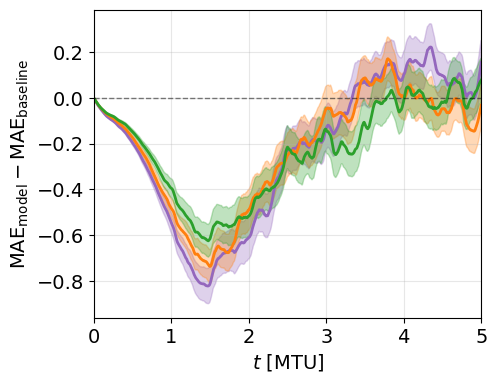

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_MAE_weather(X_true, Xs, model_names, trunc_sims=None, fig=None, ax=None, colors=None):
    if colors is None:
        colors = ['tab:blue', 'tab:purple', 'tab:orange', 'tab:green']
    
    if fig is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    
    if trunc_sims:
        Xs = [X[:trunc_sims] for X in Xs]
        X_true = X_true[:trunc_sims]

    n_sims = X_true.shape[0]
    t = np.arange(X_true.shape[1]) * 0.001 - 2
    
    # --- Compute baseline MAE (per simulation) ---
    MAE_base = np.sum(np.absolute(X_true - Xs[0]), axis=2) / 8  # Shape: (n_sims, n_time)
    mean_MAE_base = np.mean(MAE_base, axis=0)
    
    # --- Plot differences for each model ---
    for X, model_name, color in zip(Xs[1:], model_names[1:], colors[1:]):
        MAE = np.sum(np.absolute(X_true - X), axis=2) / 8
        
        # --- Compute difference PER SIMULATION (paired comparison) ---
        MAE_diff = MAE - MAE_base  # Shape: (n_sims, n_time)
        mean_diff = np.mean(MAE_diff, axis=0)
        std_diff = np.std(MAE_diff, axis=0)
        se_diff = std_diff / np.sqrt(n_sims)  # Standard error
        
        # --- Plot mean difference with uncertainty band ---
        ax.plot(t, mean_diff, label=model_name, c=color, linewidth=2)
        ax.fill_between(t, mean_diff - se_diff, mean_diff + se_diff, 
                        alpha=0.3, color=color, label=None)
    
    ax.set(xlim=(0, 5.0), xlabel=r'$t$ [MTU]', 
           ylabel=r'$\text{MAE}_\text{model} - \text{MAE}_\text{baseline}$')
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(alpha=0.3)
    
    return fig, ax

# Usage
plot_MAE_weather(Xw_true, Xs, model_names)

In [23]:
FS = 14
plt.rcParams.update({
    "font.size": FS,              # base font size
    "axes.labelsize": FS,         # x/y labels
    "xtick.labelsize": FS,        # x tick labels
    "ytick.labelsize": FS,        # y tick labels
    "legend.fontsize": FS,        # legend
    'axes.linewidth': 0.8,
    'lines.linewidth': 2.0
})


In [24]:
plt.rcParams.keys()

KeysView(RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'b

/tmp/ipykernel_398702/2948821995.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


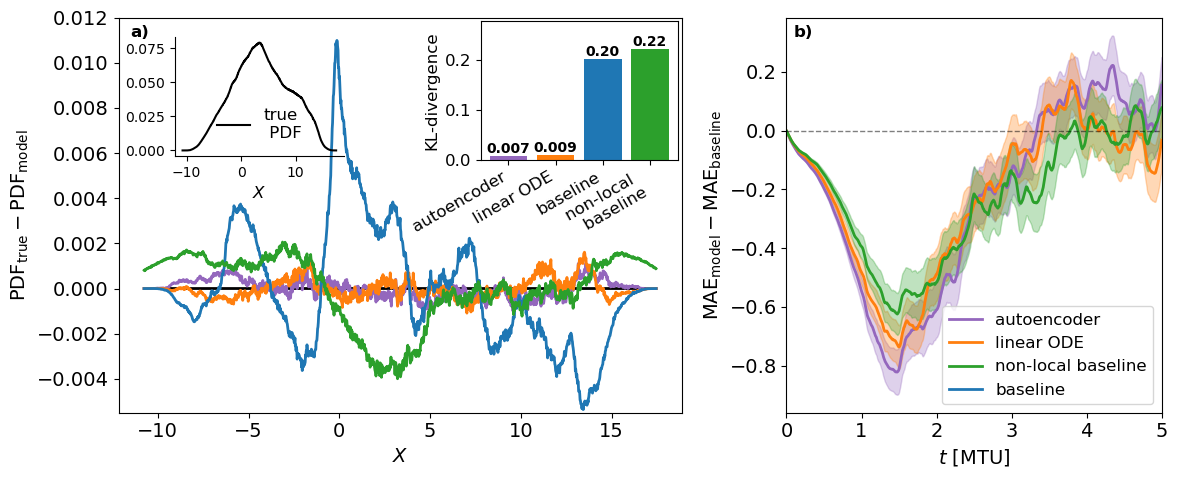

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import rel_entr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ----------------------
# Figure with 60/40 split
# ----------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [3, 2.0]}
)

# ----------------------
# Axis labels
# ----------------------
ax1.set(
    xlabel=r'$X$',
    ylabel=r'$\text{PDF}_{\text{true}} - \text{PDF}_{\text{model}}$'
)
# ----------------------
# True Distribution Inset (in ax1 - upper left with custom x-padding)
# ----------------------
ax_true = inset_axes(
    ax1,
    width="30%",
    height="30%",
    loc="upper left",
    borderpad=0,
    bbox_to_anchor=(0.10, -0.05, 1, 1),
    bbox_transform=ax1.transAxes
)

ax_true.plot(Xbins[1:], P_X_true, c='black', linewidth=1.5, label='true\n PDF', zorder=0)
ax_true.legend(loc='lower center', fontsize=12, frameon=False)
ax_true.set_xlabel(r'$X$', fontsize=12)
ax_true.tick_params(axis='both', labelsize=10)
ax_true.spines['top'].set_visible(False)
ax_true.spines['right'].set_visible(False)
ax_true.set_facecolor('none')
# ----------------------
# Compute KL + plot curves
# ----------------------
kl_values = []
eps = 1.e-12
model_names[-1] = 'non-local \n baseline'
for P_X, model_name, color in zip(P_Xs, model_names, colors):
    kl = np.sum(rel_entr(P_X_true, P_X + eps))
    kl_values.append(kl)

    ax1.plot(
        Xbins[1:],
        P_X - P_X_true,
        label=model_name,
        c=color
    )

# True reference line
ax1.plot(
    Xbins[1:],
    P_X_true - P_X_true,
    label='true',
    c='black',
    zorder=0
)

# ----------------------
# KL bar plot (inset in ax1 - upper right)
# ----------------------
ax_kl = inset_axes(
    ax1,
    width="35%",
    height="35%",
    loc="upper right",
    borderpad=0.2
)

# Create bars and store the container for labeling
bars = ax_kl.bar(model_names, kl_values, color=colors)

# Add value labels on top of each bar
for bar, kl_val in zip(bars, kl_values):
    height = bar.get_height()
    
    # Format value (adjust decimal places as needed)
    if kl_val < 0.01:
        label_text = f'{kl_val:.3f}'  # 3 decimals for small values
    else:
        label_text = f'{kl_val:.2f}'  # 2 decimals for larger values
    
    ax_kl.text(
        bar.get_x() + bar.get_width() / 2,  # x-position (center of bar)
        height,                              # y-position (top of bar)
        label_text,                          # text to display
        ha='center',                         # horizontal alignment
        va='bottom',                         # vertical alignment
        fontsize=10,                          # font size
        fontweight='bold'                   # make it stand out
    )

ax_kl.set_ylabel("KL-divergence", fontsize=12)
ax_kl.set_xticks(range(len(model_names)))
ax_kl.set_xticklabels(model_names, rotation=30, ha='right', fontsize=12)
ax_kl.tick_params(axis='both', labelsize=12)

# Optional: Add some space above bars for labels
ax_kl.set_ylim(0, max(kl_values) * 1.25)  # 25% extra space on top

# ----------------------
# MAE Weather Plot (ax2)
# ----------------------
plot_MAE_weather(Xw_true, Xs, ['baseline', 'autoencoder', 'linear ODE', 'non-local baseline'], None, fig, ax2)
ax2.grid()
ax2.plot([], [], label='baseline', color='tab:blue')  # Dummy scatter for legend
ax2.legend(loc='lower right', fontsize=12)

# ----------------------
# Subplot labels
# ----------------------
labels = ["a)", "b)"]

for ax, label in zip([ax1, ax2], labels):
    ax.text(
        0.02, 0.98,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold"
    )

ax1.set_ylim(-0.0055, 0.012)

# ----------------------
# Layout
# ----------------------
plt.tight_layout()
plt.savefig('L96_climate_weather.png', dpi=300, bbox_inches='tight')

In [5]:
model = torch.load('hyper_opt/latent_dims=6/m=0.001_tau=0.001_hyper_opt_w=1e-06_20260529134345.pkl', map_location='cpu', weights_only=False)
np.mean(model.nonlinear_predictability)

np.float32(0.9362991)

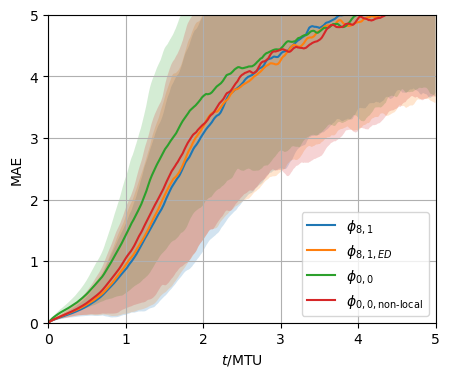

In [10]:
plot_MAE_weather(Xw_true, Xs, model_names, trunc_sims=300)

In [ ]:
X = X_base
MAE = np.sum(np.absolute(X_true - X), axis=2)
cum_MAE = np.cumsum(MAE)
cum_MAE.shape

(650000,)

In [110]:
L96 = xr.open_dataset('weather_runs/m=0.001_tau=0.001_t=500MTU_20250917165936.nc')
X, Y = L96.X.values, L96.Y.values
for i in range(50):
    initX = X[i*10_000]
    initY = Y[i*10_000]
    print(initY)

[ 0.44313434  0.07466563  0.17531428 -0.73402554 -0.03214285 -0.5315046
 -1.029402    0.87948364  0.26628226  0.26893178  0.59294987  0.20581232
 -0.34392017 -0.40922052  0.02180542 -0.81449956  0.62124014  0.370304
 -0.88551575  0.7802016  -0.51673245  0.83462125  0.1518636  -0.62519175
  0.9130691   0.47025618 -0.11877502 -0.27360705 -0.35832307  0.24016817
  0.7055647   0.3658802   0.7760038   0.10549017  0.7696955  -0.90079886
  0.6419834   0.6062753   0.80236644  0.05003856  0.8848692   0.85970885
  0.8963961   0.01693948 -0.9712008  -0.6520722  -0.75248384 -0.6312376
  0.11651611  0.08861679 -0.521804    0.07694325  0.06292102  0.26779747
 -0.6816653   0.11194724 -0.6203284  -0.6687466  -0.80418575  0.44870996
  0.530832   -0.3618016   0.6600533   0.23262025 -0.07563963  0.4386627
  1.0544147   0.51835537 -0.7235462   0.00613656  0.778845    0.006453
 -0.460285    0.09190533  0.8242679  -0.79641575  0.10306646  0.84990907
  0.8223299  -0.37067983 -0.1597173  -0.55688983 -0.082023

(2000.0, 10000.0)

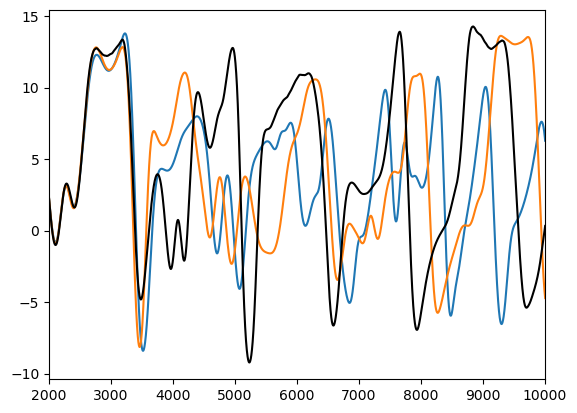

In [ ]:
seed=0
plt.plot(X_base[seed,:,0])
plt.plot(X_ODE[seed,:,0])
plt.plot(X_true[seed,:,0], color='black')
plt.xlim(2000, 10000)

array([-6.35016539, -6.49096488,  0.63102748,  0.63655174,  2.68801917,
        6.98863588,  4.4891065 ,  2.22047021])

# Parametrization of $B$ 

[0.83989358 0.83667278 0.8298198  0.82599336 0.80909568 0.77126145
 0.64675999 0.39626199 0.12764168 0.06219363]
[0.93075764 0.9267149  0.93924069 0.93518043 0.93557727 0.9361037
 0.93269205 0.93767095 0.94068331 0.90903306]
[0.93728817 0.93001568 0.94240129 0.93812895 0.93941343 0.93742925
 0.93880802 0.94133729 0.94424188 0.9151004 ]
[0.93546903 0.92964733 0.93862683 0.93591106 0.93725848 0.93663156
 0.93337047 0.93849164 0.94164866 0.91140431]


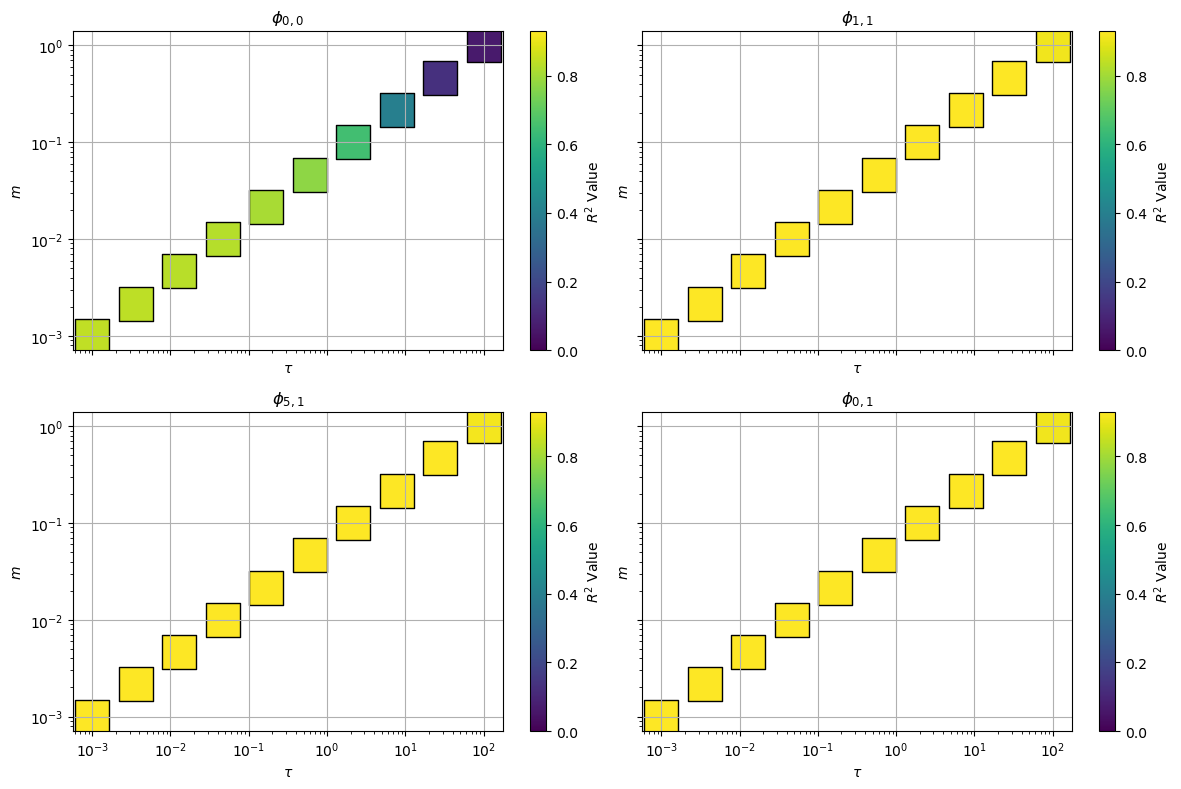

In [16]:
fig , axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for mname, pt, title, ax in zip(['baseline_nn', 'NN+AE_latent_dims=1', 'NN+AE_latent_dims=5', 'nn'], [0, 1000, 1000, 1000], [r'$\phi_{0,0}$', r'$\phi_{1,1}$', r'$\phi_{5,1}$', r'$\phi_{0,1}$'], axs.flatten()):
    memory_sensitivity(mname, past_timesteps=pt, fig=fig, ax=ax, vmin=0, vmax=.93)
    ax.title.set_text(title)
plt.tight_layout()

Text(0.5, 1.0, '$\\phi_{1,1}$ - $\\phi_{0,1}$')

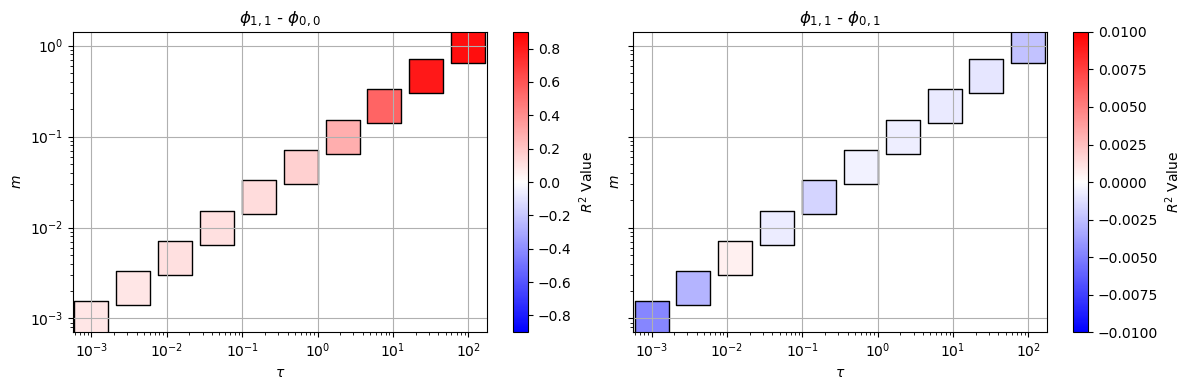

In [54]:
# Sensitivity to memory parameters
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
memory_sensitivity('NN+AE_latent_dims=1', past_timesteps=1000, minus=['baseline_nn', 0], cmap='bwr', vmin=-.9, vmax=.9, fig=fig, ax=axs[0])
axs[0].set_title(r'$\phi_{1,1}$ - $\phi_{0,0}$')
memory_sensitivity('NN+AE_latent_dims=1', past_timesteps=1000, minus=['nn', 1000], cmap='bwr', vmin=-.01, vmax=.01, fig=fig, ax=axs[1])
axs[1].set_title(r'$\phi_{1,1}$ - $\phi_{0,1}$')

[0.93075764 0.9267149  0.93924069 0.93518043 0.93557727 0.9361037
 0.93269205 0.93767095 0.94068331 0.90903306]


Text(0.5, 1.0, '$\\phi_{1,1,1}$')

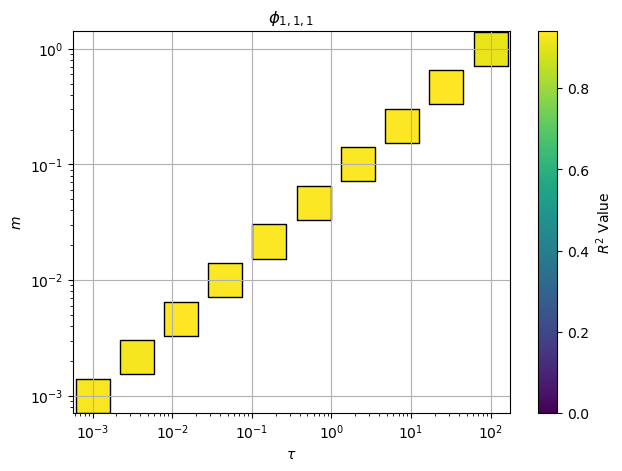

In [11]:
memory_sensitivity('NN+AE_latent_dims=1', past_timesteps=1000, minus=None, vmax=.94)
plt.title(r'$\phi_{1,1,1}$')

[0.92211074 0.91825151 0.92507601 0.91933519 0.91850984 0.91791016
 0.90784645 0.86788082 0.69852459 0.36408621]


Text(0.5, 1.0, '$\\phi_{0,0,8}$')

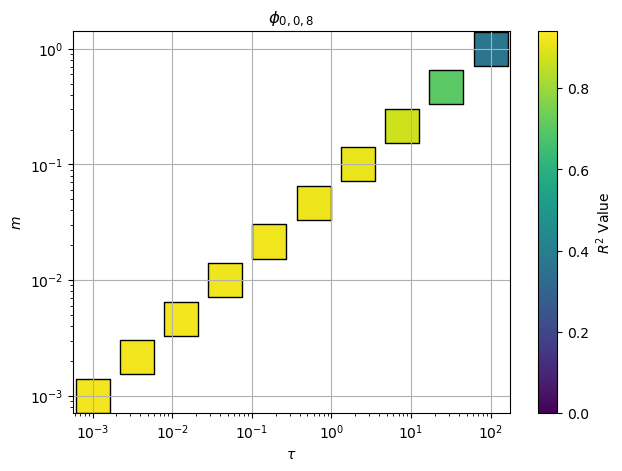

In [10]:
memory_sensitivity('NN', past_timesteps=0, minus=None, vmax=.94)
plt.title(r'$\phi_{0,0,8}$')

[0.83989358 0.83667278 0.8298198  0.82599336 0.80909568 0.77126145
 0.64675999 0.39626199 0.12764168 0.06219363]


Text(0.5, 1.0, '$\\phi_{0,0,1}$')

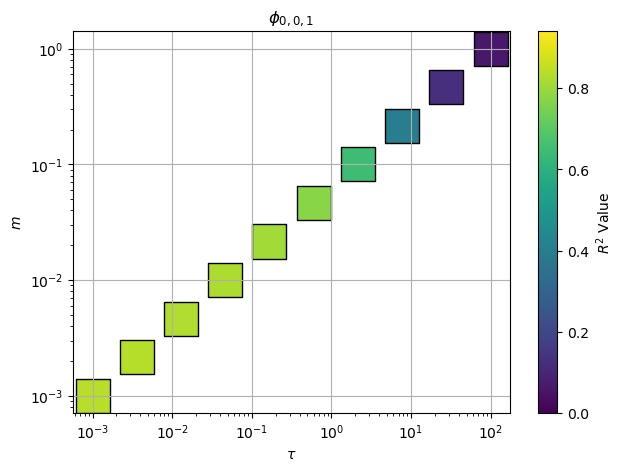

In [13]:
memory_sensitivity('baseline_nn', past_timesteps=0, minus=None, vmax=.94)
plt.title(r'$\phi_{0,0,1}$')

[0.93546903 0.92964733 0.93862683 0.93591106 0.93725848 0.93663156
 0.93337047 0.93849164 0.94164866 0.91140431]


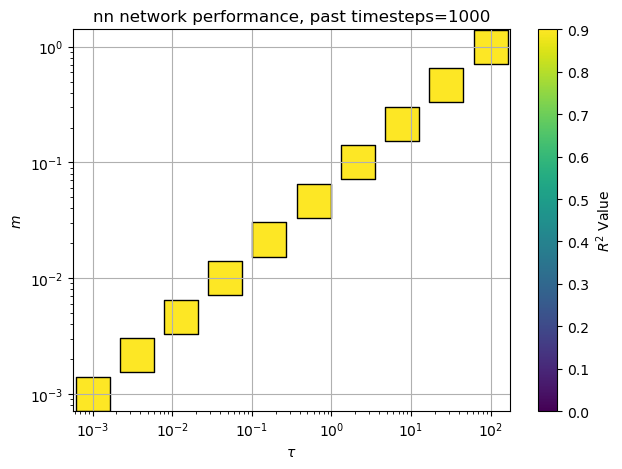

In [118]:
memory_sensitivity('nn', past_timesteps=1000, minus=None)

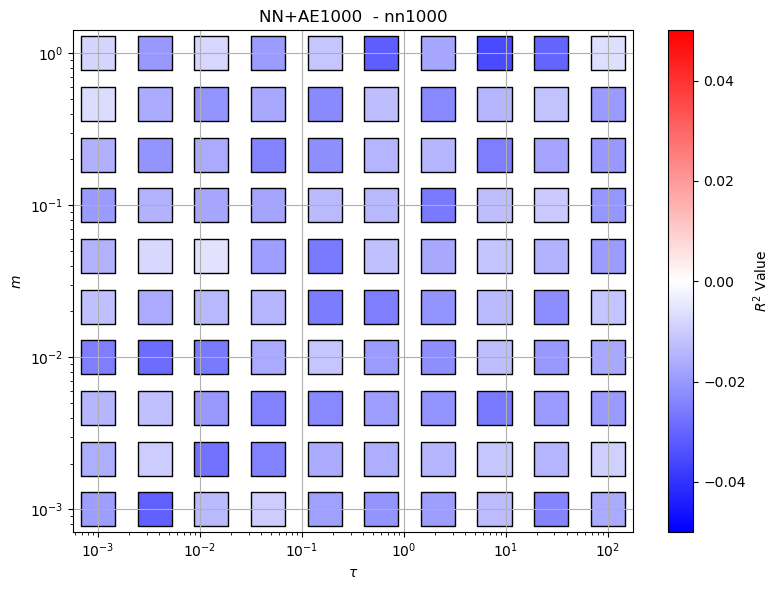

In [17]:
memory_sensitivity('NN+AE', past_timesteps=1000, minus=['nn', 1000], vmin=-.05, vmax=.05, cmap='bwr')

In [ ]:
Nt = 1000 * 1000
m, tau = .001, .001
with open('online_runs/NO_PARAMETRIZATION/time=10000000_m=0.001_tau=0.001.pkl', 'rb') as file:
    L96 = pickle.load(file)
    L96_subset = L962LvlMem(m=m, tau=tau)
    L96_subset._history_X = L96._history_X[:Nt]
    L96_subset._history_B = L96._history_B[:Nt]
    L96 = L96_subset

Memory steps: 1


: 

In [ ]:
past_timesteps = 1000
model811 = NNpAE(past_timesteps, 8)
model811.mmemory_cutoff, model811.tau = m, tau
X_train, X_test, B_train, B_test = generate_data(L96, past_timesteps)

In [ ]:
train_model(X_train, X_test, B_train, B_test, model811, num_epochs=2_000);

Training: 100%|████████████████████████████| 2000/2000 [04:43<00:00,  7.06it/s, Train Loss=1.3447, Test Loss=1.3233, R²=0.9369, Best R²=0.9388 @ 1956]


NNpAE(
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=12, bias=True)
    (5): ReLU()
    (6): Linear(in_features=12, out_features=8, bias=True)
  )
  (neural_net): Sequential(
    (0): Linear(in_features=9, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [5]:
model = set_model_metadata(model811, past_timesteps, 8, model_name='NN+AE', m=m, tau=tau)
save_model(model)

# Add non-local variables to AE

In [3]:
# L96 = L962LvlMem(m=.001, tau=.001)
# L96.iterate(1000)

In [4]:
def load_data(dim):
    X = np.load(f'/work/bd1179/b309297/L96/latent_space_data/dim={dim}_t=5000MTU_pt=1000_m=0.001_tau=0.001/X.npy').reshape(-1, 8, 1)
    B = np.load(f'/work/bd1179/b309297/L96/latent_space_data/dim={dim}_t=5000MTU_pt=1000_m=0.001_tau=0.001/B.npy').reshape(-1, 8)
    Z = np.load(f'/work/bd1179/b309297/L96/latent_space_data/dim={dim}_t=5000MTU_pt=1000_m=0.001_tau=0.001/Z.npy').reshape(-1, 8, dim)
    T = np.arange(B.shape[0]) * 0.001
    return X, B, Z, T

dim = 3
X, B, Z, T = load_data(dim)
discover_MTUs = 1000 * 1000
X = X[:discover_MTUs][:,:,0]
B = B[:discover_MTUs]
# Z = Z[:discover_MTUs]
T = T[:discover_MTUs]

# X = L96.history.X.values
# B = L96.history.B.values

In [3]:
with open('online_runs/NO_PARAMETRIZATION/time=10000000_m=0.001_tau=0.001.pkl', 'rb') as file:
    L96 = pickle.load(file)

X = L96.history.X.values[:100_000]
B = L96.history.B.values[:100_000]
#Z = L96.history.Z.values

#plt.plot(X[2000:5000, 1])
#plt.plot(B[2000:5000, 1])
#plt.plot(Z[2000:5000, 1, 0])

In [18]:
X1 = return_lagged_input_vector(B.T, 1000)
X2 = return_lagged_input_vector_opt(B.T, 1000)

In [19]:
np.all((X1 == X2) == True)

np.True_

In [5]:
class NN(nn.Module):
    def __init__(self,past_timesteps, n_neighbours, nodes_per_layer=16):
        super().__init__()
        self.past_timesteps = past_timesteps
        self.n_neighbours = n_neighbours
        self.nodes_per_layer = nodes_per_layer

        self.neural_net = nn.Sequential(
            nn.Linear(self.past_timesteps + self.n_neighbours, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )

        # Loss
        self.train_loss = []
        self.test_loss = []

        # R^2
        self.R2 = []

        # Metadata
        self.memory_cutoff = None
        self.tau = None
        self.model_name = 'NN'
        self.latent_dims = 0

    def forward(self, x):
        y_pred = self.neural_net(x)
        return y_pred
    
class NNpAE(nn.Module):
    def __init__(self, past_timesteps, n_neighbours, latent_dims, nodes_per_layer=16):
        super().__init__()

        self.past_timesteps = past_timesteps
        self.n_neighbours = n_neighbours
        self.latent_dims = latent_dims
        self.nodes_per_layer = nodes_per_layer

        self.encoder = nn.Sequential(
            nn.Linear(self.past_timesteps, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, self.latent_dims)
        )

        self.neural_net = nn.Sequential(
            nn.Linear(latent_dims + n_neighbours, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )

        # Loss
        self.train_loss = []
        self.test_loss = []

        # R^2
        self.R2 = []

        # Metadata
        self.memory_cutoff = None
        self.tau = None
        self.model_name = 'NN+AE'

    def forward(self, x):
        x_past = x[:, :self.past_timesteps]
        x_present = x[:, self.past_timesteps:]

        latent_space = self.encoder(x_past)
        x_nn = torch.cat((latent_space, x_present), dim=1)

        y_pred = self.neural_net(x_nn)
        
        return y_pred


def train_model_NN(x, x_test, dZdt, dZdt_test, model, num_epochs=5):
    # Send to gpu if available
    model = model.to(device)
    criterion = nn.MSELoss()
    lr = .007
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Make progress bar
    best_R2 = float('-inf')
    best_R2_epoch = 0
    pbar = trange(num_epochs, desc="Training", ncols=150)

    # Training
    for epoch in pbar:
        model.train()
        test_loss, train_loss, R2 = 0, 0, 0

        # Transpose 1-dimensional data
        dZdt_pred = model.forward(x)
        loss = criterion(dZdt_pred, dZdt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            # Transpose 1-dimensional data
            dZdt_pred = model.forward(x_test)
            loss = criterion(dZdt_pred, dZdt_test)
            R2 += R2Score().to(device)(dZdt_pred, dZdt_test)
            test_loss += loss.item()
        
        train_loss = train_loss 
        test_loss = test_loss 
        model.train_loss.append(train_loss)
        model.test_loss.append(test_loss)
        model.R2.append(R2)

        # Update best R²
        if R2 > best_R2:
            best_R2 = R2
            best_R2_epoch = epoch + 1

        # Inline update
        pbar.set_postfix({
            "Train Loss": f"{train_loss:.4f}",
            "Test Loss": f"{test_loss:.4f}",
            "R²": f"{R2:.4f}",
            "Best R²": f"{best_R2:.4f} @ {best_R2_epoch}"})
    
    return model

In [21]:
#path = 'networks/phi_0_1.0_8_m=None_tau=None_20250717114600.pkl'
#path = 'networks/phi_0_0.0_8_m=None_tau=None_20250717112413.pkl'
#path = 'networks/phi_1_1.0_8_m=0.001_tau=0.001_20250717104927.pkl'
path = 'networks/NN+AE_latent_dims=5/input_lagg=1000/m=0.001_tau=0.001_NN+AE.pkl'
model = torch.load(path, weights_only=False, map_location='cpu')

In [23]:
r2 = np.array([r2.numpy() for r2 in model.R2])

(2000,)

In [6]:
def train_test_split(arr, Ntrain):
    return arr[:Ntrain], arr[Ntrain:]

In [ ]:
Ntrain = int(X.shape[0] * .8)
def train_test_split(arr, Ntrain):
    return arr[:Ntrain], arr[Ntrain:]

X_train, X_test = train_test_split(X, Ntrain)
B_train, B_test = train_test_split(B, Ntrain)

past_timesteps = 1000

X_train = torch.tensor(return_lagged_input_vector_and_present_k(X_train.T, past_timesteps), dtype=torch.float32, device=device)
X_test = torch.tensor(return_lagged_input_vector_and_present_k(X_test.T, past_timesteps), dtype=torch.float32, device=device)
B_train = torch.tensor(B_train[past_timesteps:].T.flatten().reshape(-1, 1), dtype=torch.float32, device=device)
B_test = torch.tensor(B_test[past_timesteps:].T.flatten().reshape(-1, 1), dtype=torch.float32, device=device)

print(X_train.shape, B_train.shape)
print(past_timesteps)
model = NNpAE(past_timesteps, n_neighbours=8, latent_dims=1)
model.tau = 0.001
model.memory_cutoff = 0.001
model = train_model(X_train, X_test, B_train, B_test, model, num_epochs=10_000)
save_model(model)

torch.Size([6384000, 2008]) torch.Size([6384000, 1])
2000


Training: 100%|██████████████████████████| 10000/10000 [30:21<00:00,  5.49it/s, Train Loss=1.2899, Test Loss=1.3350, R²=0.9364, Best R²=0.9371 @ 9759]


In [ ]:
print(past_timesteps)
model = NNpAE(past_timesteps, n_neighbours=8, latent_dims=1)
model.tau = 0.001
model.memory_cutoff = 0.001
model = train_model(X_train, X_test, B_train, B_test, model, num_epochs=10_000)


100


Training: 100%|███████████████████████████████| 300/300 [00:34<00:00,  8.65it/s, Train Loss=1.8221, Test Loss=1.8235, R²=0.9131, Best R²=0.9131 @ 300]


In [26]:
def save_model(model):
    exp_id = datetime.datetime.now().strftime('%Y%m%d%H%M%S')
    path = f'networks/phi_{model.latent_dims}_{model.past_timesteps/1000}_{model.n_neighbours}_m={model.memory_cutoff}_tau={model.tau}_{exp_id}.pkl'
    torch.save(model, path)

In [34]:
past_timesteps = 1000
X_train, X_test = train_test_split(X, Ntrain)
B_train, B_test = train_test_split(B, Ntrain)

X_train = torch.tensor(return_lagged_input_vector_and_present_k(X_train.T, past_timesteps), dtype=torch.float32, device=device)
X_test = torch.tensor(return_lagged_input_vector_and_present_k(X_test.T, past_timesteps), dtype=torch.float32, device=device)
B_train = torch.tensor(B_train[past_timesteps:].T.flatten().reshape(-1, 1), dtype=torch.float32, device=device)
B_test = torch.tensor(B_test[past_timesteps:].T.flatten().reshape(-1, 1), dtype=torch.float32, device=device)
print(past_timesteps)
model = NN(past_timesteps=past_timesteps, n_neighbours=8)
train_model(X_train, X_test, B_train, B_test, model, num_epochs=10_000)
save_model(model)

1000


Training: 100%|██████████████████████████| 10000/10000 [16:55<00:00,  9.85it/s, Train Loss=1.2619, Test Loss=1.2867, R²=0.9387, Best R²=0.9390 @ 9886]


In [113]:
model = NNpAE(past_timesteps, n_neighbours=8, latent_dims=1)
train_model(X_train, X_test, B_train, B_test, model, num_epochs=10_000)

Training: 100%|██████████████████████████| 10000/10000 [22:19<00:00,  7.47it/s, Train Loss=1.2713, Test Loss=1.2607, R²=0.9399, Best R²=0.9413 @ 9714]


NNpAE(
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=12, bias=True)
    (5): ReLU()
    (6): Linear(in_features=12, out_features=1, bias=True)
  )
  (neural_net): Sequential(
    (0): Linear(in_features=9, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [109]:
model = NNpAE(past_timesteps, n_neighbours=8, latent_dims=3)
train_model(X_train, X_test, B_train, B_test, model, num_epochs=10_000)

Training:   0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

Training: 100%|██████████████████████████| 10000/10000 [23:16<00:00,  7.16it/s, Train Loss=1.2293, Test Loss=1.2660, R²=0.9397, Best R²=0.9410 @ 9913]


NNpAE(
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=12, bias=True)
    (5): ReLU()
    (6): Linear(in_features=12, out_features=3, bias=True)
  )
  (neural_net): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [7]:
Ntrain = int(X.shape[0] * .8)
def train_test_split(arr, Ntrain):
    return arr[:Ntrain], arr[Ntrain:]
X_train, X_test = train_test_split(X, Ntrain)
B_train, B_test = train_test_split(B, Ntrain)

past_timesteps = 1000

X_train = torch.tensor(return_lagged_input_vector_opt(X_train.T, past_timesteps), dtype=torch.float32, device=device)
X_test = torch.tensor(return_lagged_input_vector_opt(X_test.T, past_timesteps), dtype=torch.float32, device=device)
B_train = torch.tensor(return_lagged_input_vector_opt(B_train.T, past_timesteps), dtype=torch.float32, device=device)[:,0].reshape(-1,1)
B_test = torch.tensor(return_lagged_input_vector_opt(B_test.T, past_timesteps), dtype=torch.float32, device=device)[:,0].reshape(-1,1)

In [ ]:
with open('online_runs/NN/input_lagg=0/time=1000MTU_m=0.001_tau=0.001.pkl', 'rb') as file:
    L96 = pickle.load(file)

X = L96.history.X.values
B = L96.history.B.values
X = X[:500_000]
B = B[:500_000]

Ntrain = int(X.shape[0] * .8)
def train_test_split(arr, Ntrain):
    return arr[:Ntrain], arr[Ntrain:]

X_train, X_test = train_test_split(X, Ntrain)
B_train, B_test = train_test_split(B, Ntrain)

past_timesteps = 1000

X_train = torch.tensor(return_lagged_input_vector_opt(X_train.T, past_timesteps), dtype=torch.float32, device=device)
X_test = torch.tensor(return_lagged_input_vector_opt(X_test.T, past_timesteps), dtype=torch.float32, device=device)
B_train = torch.tensor(return_lagged_input_vector_opt(B_train.T, past_timesteps), dtype=torch.float32, device=device)[:,0].reshape(-1,1)
B_test = torch.tensor(return_lagged_input_vector_opt(B_test.T, past_timesteps), dtype=torch.float32, device=device)[:,0].reshape(-1,1)

for w in [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]:
    print(w)
    model = NNpAEpD(n_neighbours=1, past_timesteps=past_timesteps, latent_dims=8)
    model = train_model_NNpAEpD(X_train, X_test, B_train, B_test, model, num_epochs=5000, weight_decay=w)
    save_model(model, w=w)

0.0001


Training:  13%|███▉                          | 666/5000 [02:29<16:12,  4.46it/s, Train Loss=5.7443, Test Loss=5.9330, R²=0.0809, Best R²=0.0902 @ 653]


KeyboardInterrupt: 

In [16]:
save_model(model)

In [17]:
model = torch.load('networks/NN+AE+D/input_lagg=1000/m=None_tau=None_NN+AE+D.pkl', weights_only=False)

In [20]:
X_test.shape
b, x_recon = model.forward(X_test)

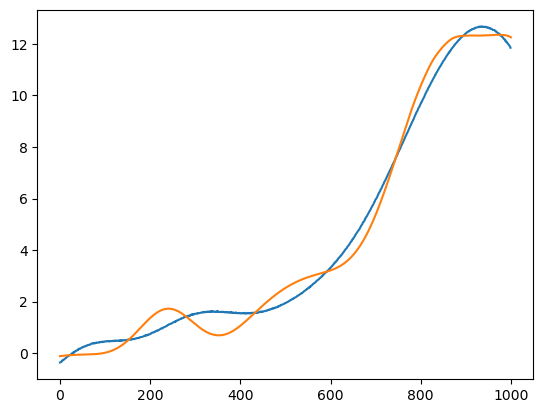

In [44]:
#b, x_recon = b.detach().cpu().numpy(), x_recon.detach().cpu().numpy()
#x_test = X_test.detach().cpu().numpy()
idx = 10294
plt.plot(x_recon[idx])
plt.plot(x_test[idx])

In [95]:
k = 2
ks = np.arange(k+1, k + 8)

ks % 8

array([3, 4, 5, 6, 7, 0, 1])

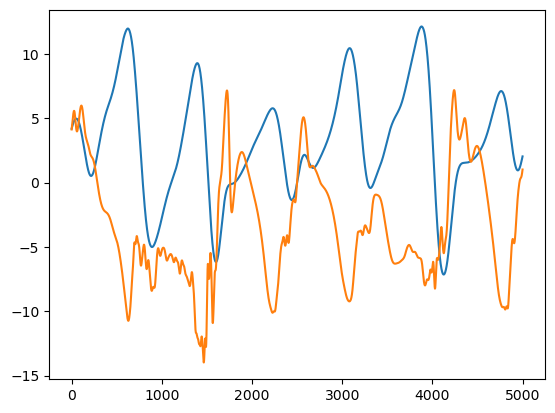

In [29]:
plt.plot(X[:5000, 7])
plt.plot(B[:5000, 0])

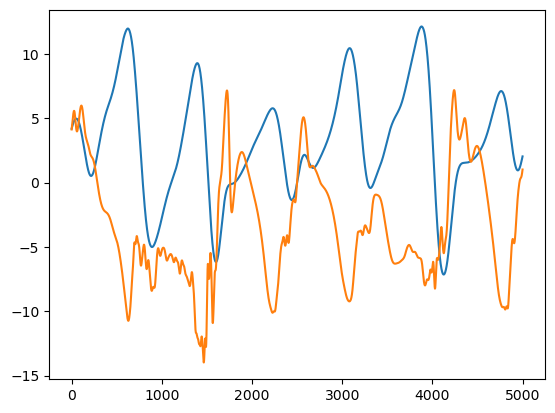

In [30]:
plt.plot(X_train[:5000, 7].cpu().numpy())
plt.plot(B_train[:5000, 0].cpu().numpy())

In [28]:
X_lagged.shape

(6399200, 108)

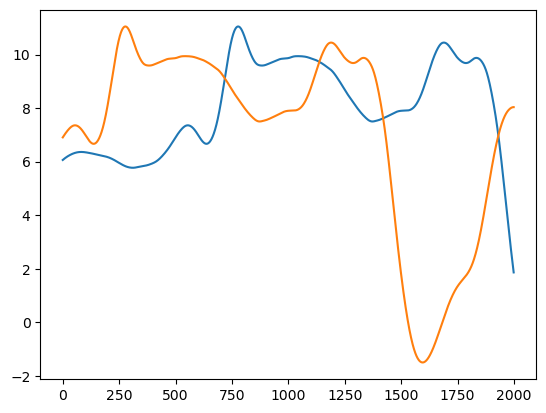

In [26]:
# plt.plot(Xks_lagged[:5000, 0, -1].cpu().numpy(), label='data')
# plt.plot(Xks_lagged[:5000, 0, 500].cpu().numpy(), label='lagged data')
# plt.legend()

plt.plot(X_lagged[:2000, 500])
plt.plot(X_lagged[:2000, 1000])
#plt.plot(X_lagged[:2000, 1001])

In [73]:
model = FCNN(past_timesteps=0)

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'memory cutoff=0.001, tau=0.001'}, xlabel='X (resolved variable)', ylabel='B (sub-grid term)'>)

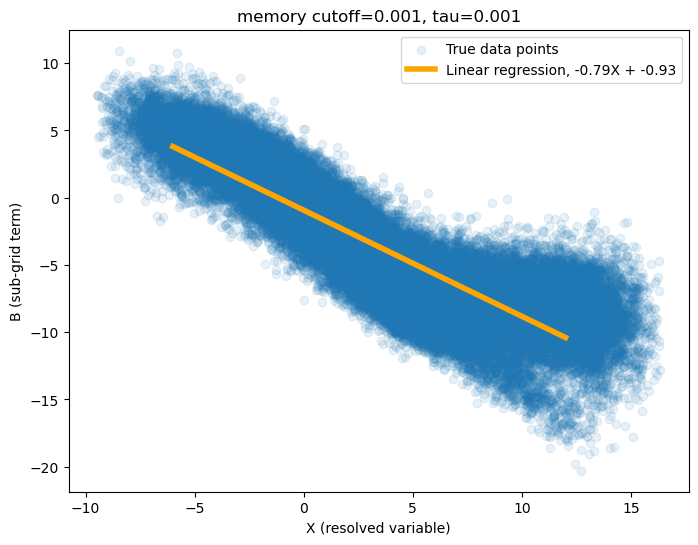

In [70]:
#plt.plot(X_train[:5000, 4].cpu().numpy())
#plt.scatter(X_train[:5000, 4].cpu().numpy(), B_train[:5000, 4].cpu().numpy())
linear_regression_fit(L96)

In [74]:
train_model(X_train[:, 7].reshape(-1, 1), X_test[:, 7].reshape(-1, 1), 
            B_train[:, 7].reshape(-1, 1), B_test[:, 7].reshape(-1, 1), 
            model, num_epochs=10000)

Training:   3%|▋                           | 253/10000 [00:01<01:03, 153.91it/s, Train Loss=3.3901, Test Loss=3.3752, R²=0.8377, Best R²=0.8377 @ 262]

Training: 100%|█████████████████████████| 10000/10000 [01:07<00:00, 148.83it/s, Train Loss=3.3820, Test Loss=3.3686, R²=0.8381, Best R²=0.8381 @ 8286]


FCNN(
  (linear1): Linear(in_features=1, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=16, bias=True)
  (linear3): Linear(in_features=16, out_features=16, bias=True)
  (linear4): Linear(in_features=16, out_features=16, bias=True)
  (linear5): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)

In [13]:
model = NNpAE(past_timesteps, 8, 3)
train_model(Xks_lagged, Xks_test_lagged, Bks_lagged, Bks_test_lagged, model=model, num_epochs=5000);

Training:   0%|                                                                                                              | 0/5000 [00:00<?, ?it/s]

Training: 100%|████████████████████████████| 5000/5000 [08:34<00:00,  9.72it/s, Train Loss=1.1023, Test Loss=1.6495, R²=0.9242, Best R²=0.9312 @ 1096]


In [24]:
model = NNpAE(past_timesteps, 8, 3)
print(past_timesteps)
train_model(Xks_lagged, Xks_test_lagged, Bks_lagged, Bks_test_lagged, model=model, num_epochs=5000);

1


Training: 100%|████████████████████████████| 5000/5000 [01:14<00:00, 67.43it/s, Train Loss=1.3987, Test Loss=1.6952, R²=0.9224, Best R²=0.9242 @ 3778]


In [33]:
model = NNpAE(past_timesteps, 8, 3)
print(past_timesteps)
train_model(Xks_lagged, Xks_test_lagged, Bks_lagged, Bks_test_lagged, model=model, num_epochs=5000);

500


Training: 100%|████████████████████████████| 5000/5000 [05:12<00:00, 15.98it/s, Train Loss=1.1358, Test Loss=1.5721, R²=0.9279, Best R²=0.9317 @ 1163]
